# MVP de Machine Learning & Analytics
## Classificação de defeitos em chapas de aço

**Aluno**: Enzo de Sousa Lopes

Neste MVP eu usei uma base pública da UCI para prever o tipo de defeito em chapas de aço a partir de atributos numéricos de inspeção.

**Problema:** classificar automaticamente o defeito identificado na chapa.  
**Tipo de ML:** classificação multiclasse supervisionada.  
**Base:** Steel Plates Faults — UCI Machine Learning Repository.  
**Fonte:** https://archive.ics.uci.edu/dataset/198/steel+plates+faults

Escolhi essa base porque ela tem relação com qualidade industrial, é simples de carregar no Colab e permite montar um fluxo completo de Machine Learning sem depender de login, token ou upload manual.

## 1. Ambiente

Importação das bibliotecas e definição da seed para manter os resultados mais estáveis entre execuções.

In [1]:
import os
import time
import zipfile
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Carregamento dos dados

A base possui 27 atributos de entrada e 7 colunas finais indicando a classe do defeito. Essas 7 colunas estão no formato one-hot, então depois vou transformar isso em uma única variável-alvo.

In [2]:
DATA_URLS = [
    "https://archive.ics.uci.edu/static/public/198/steel+plates+faults.zip",
    "https://archive.ics.uci.edu/static/public/198/steel%2Bplates%2Bfaults.zip"
]

DATA_DIR = Path("steel_plates_faults")
ZIP_PATH = Path("steel_plates_faults.zip")
DATA_FILE = "Faults.NNA"

FEATURE_COLUMNS = [
    "X_Minimum", "X_Maximum", "Y_Minimum", "Y_Maximum", "Pixels_Areas",
    "X_Perimeter", "Y_Perimeter", "Sum_of_Luminosity", "Minimum_of_Luminosity",
    "Maximum_of_Luminosity", "Length_of_Conveyer", "TypeOfSteel_A300",
    "TypeOfSteel_A400", "Steel_Plate_Thickness", "Edges_Index", "Empty_Index",
    "Square_Index", "Outside_X_Index", "Edges_X_Index", "Edges_Y_Index",
    "Outside_Global_Index", "LogOfAreas", "Log_X_Index", "Log_Y_Index",
    "Orientation_Index", "Luminosity_Index", "SigmoidOfAreas"
]

TARGET_COLUMNS = [
    "Pastry", "Z_Scratch", "K_Scatch", "Stains", "Dirtiness", "Bumps", "Other_Faults"
]

ALL_COLUMNS = FEATURE_COLUMNS + TARGET_COLUMNS


def download_file(urls, output_path):
    last_error = None
    for url in urls:
        try:
            urllib.request.urlretrieve(url, output_path)
            return
        except Exception as error:
            last_error = error
    raise RuntimeError(f"Não foi possível baixar a base. Último erro: {last_error}")


if not DATA_DIR.exists():
    DATA_DIR.mkdir(exist_ok=True)

if not list(DATA_DIR.rglob(DATA_FILE)):
    download_file(DATA_URLS, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

data_path = next(DATA_DIR.rglob(DATA_FILE))
df = pd.read_csv(data_path, sep=r"\s+", header=None, names=ALL_COLUMNS)

display(df.head())
print("Dimensões:", df.shape)

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


Dimensões: (1941, 34)


## 3. Visão inicial da base

Aqui eu verifico estrutura, valores ausentes e uma noção geral das variáveis numéricas.

In [3]:
display(df.info())
display(df.describe().T.head(15))

missing = df.isna().sum()
missing[missing > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empt

None

,count,mean,std,min,25%,50%,75%,max
X_Minimum,1941.0,5.711360e+02,5.206907e+02,0.0,51.0000,4.350000e+02,1.053000e+03,1.705000e+03
X_Maximum,1941.0,6.179645e+02,4.976274e+02,4.0,192.0000,4.670000e+02,1.072000e+03,1.713000e+03
Y_Minimum,1941.0,1.650685e+06,1.774578e+06,6712.0,471253.0000,1.204128e+06,2.183073e+06,1.298766e+07
Y_Maximum,1941.0,1.650739e+06,1.774590e+06,6724.0,471281.0000,1.204136e+06,2.183084e+06,1.298769e+07
Pixels_Areas,1941.0,1.893878e+03,5.168460e+03,2.0,84.0000,1.740000e+02,8.220000e+02,1.526550e+05
X_Perimeter,1941.0,1.118552e+02,3.012092e+02,2.0,15.0000,2.600000e+01,8.400000e+01,1.044900e+04
Y_Perimeter,1941.0,8.296600e+01,4.264829e+02,1.0,13.0000,2.500000e+01,8.300000e+01,1.815200e+04
Sum_of_Luminosity,1941.0,2.063121e+05,5.122936e+05,250.0,9522.0000,1.920200e+04,8.301100e+04,1.159141e+07
Minimum_of_Luminosity,1941.0,8.454869e+01,3.213428e+01,0.0,63.0000,9.000000e+01,1.060000e+02,2.030000e+02
Maximum_of_Luminosity,1941.0,1.301937e+02,1.869099e+01,37.0,124.0000,1.270000e+02,1.400000e+02,2.530000e+02


,0


In [4]:
target_check = df[TARGET_COLUMNS].sum(axis=1).value_counts().sort_index()
target_check

,count
1,1941


Cada registro deve ter apenas uma classe marcada. Registros fora desse padrão seriam ambíguos, então são removidos antes da modelagem.

In [5]:
df_model = df.copy()
df_model["target_sum"] = df_model[TARGET_COLUMNS].sum(axis=1)
df_model = df_model[df_model["target_sum"] == 1].copy()
df_model["fault_type"] = df_model[TARGET_COLUMNS].idxmax(axis=1)

display(df_model[["fault_type"] + TARGET_COLUMNS].head())
print("Dimensões após ajuste do alvo:", df_model.shape)

,fault_type,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,Pastry,1,0,0,0,0,0,0
1,Pastry,1,0,0,0,0,0,0
2,Pastry,1,0,0,0,0,0,0
3,Pastry,1,0,0,0,0,0,0
4,Pastry,1,0,0,0,0,0,0


Dimensões após ajuste do alvo: (1941, 36)


In [6]:
target_distribution = df_model["fault_type"].value_counts().rename_axis("classe").reset_index(name="quantidade")
target_distribution["percentual"] = (100 * target_distribution["quantidade"] / target_distribution["quantidade"].sum()).round(2)
target_distribution

,classe,quantidade,percentual
0,Other_Faults,673,34.67
1,Bumps,402,20.71
2,K_Scatch,391,20.14
3,Z_Scratch,190,9.79
4,Pastry,158,8.14
5,Stains,72,3.71
6,Dirtiness,55,2.83


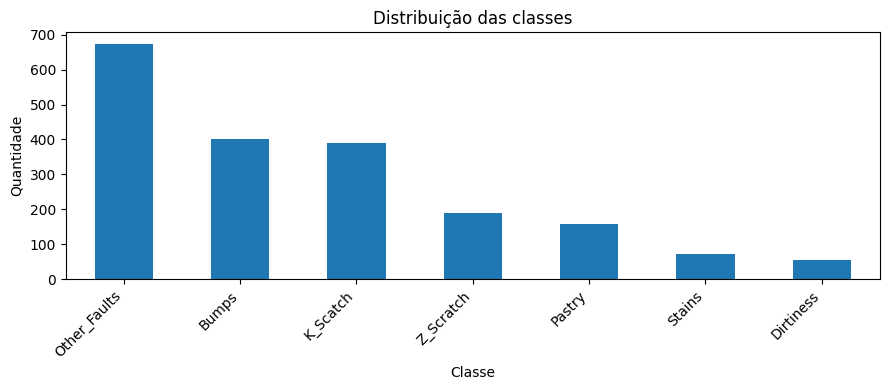

In [7]:
plt.figure(figsize=(9, 4))
df_model["fault_type"].value_counts().plot(kind="bar")
plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Existe diferença de volume entre as classes. Por isso, além da acurácia, vou usar **balanced accuracy** e **F1 macro**, que ajudam a avaliar melhor o desempenho em classes menores.

In [8]:
X_preview = df_model[FEATURE_COLUMNS]
q1 = X_preview.quantile(0.25)
q3 = X_preview.quantile(0.75)
iqr = q3 - q1

outliers = ((X_preview < (q1 - 1.5 * iqr)) | (X_preview > (q3 + 1.5 * iqr))).sum()
outliers.sort_values(ascending=False).head(10).reset_index(name="qtd_outliers_iqr")

,index,qtd_outliers_iqr
0,Sum_of_Luminosity,399
1,Pixels_Areas,395
2,Outside_X_Index,370
3,X_Perimeter,352
4,Steel_Plate_Thickness,240
5,Y_Perimeter,179
6,Maximum_of_Luminosity,146
7,Luminosity_Index,134
8,Y_Minimum,81
9,Y_Maximum,81


Não removi os outliers automaticamente, porque neste caso eles podem representar características reais dos defeitos. Remover esses pontos sem uma análise de processo poderia piorar o modelo.

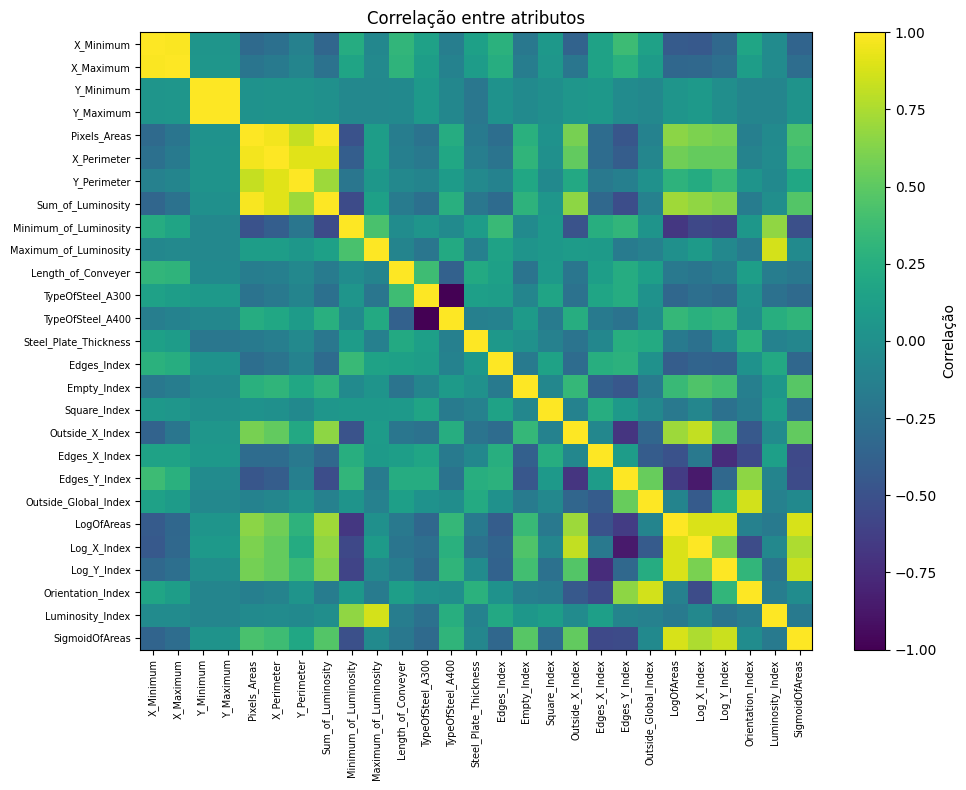

In [9]:
corr = df_model[FEATURE_COLUMNS].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlação")
plt.title("Correlação entre atributos")
plt.xticks(range(len(FEATURE_COLUMNS)), FEATURE_COLUMNS, rotation=90, fontsize=7)
plt.yticks(range(len(FEATURE_COLUMNS)), FEATURE_COLUMNS, fontsize=7)
plt.tight_layout()
plt.show()

## 4. Preparação e divisão dos dados

As colunas de classe originais não entram em `X`, porque elas são a própria resposta do problema. Mantê-las causaria vazamento de dados.

A divisão foi feita com estratificação, preservando a proporção das classes em treino e teste.

In [10]:
X = df_model[FEATURE_COLUMNS].copy()
y = df_model["fault_type"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

pd.DataFrame({
    "treino_%": (y_train.value_counts(normalize=True) * 100).round(2),
    "teste_%": (y_test.value_counts(normalize=True) * 100).round(2)
}).sort_index()

Treino: (1552, 27)
Teste: (389, 27)


,treino_%,teste_%
fault_type,,
Bumps,20.68,20.82
Dirtiness,2.84,2.83
K_Scatch,20.17,20.05
Other_Faults,34.66,34.70
Pastry,8.12,8.23
Stains,3.74,3.60
Z_Scratch,9.79,9.77


## 5. Modelagem

Usei um baseline e três modelos candidatos:

- **DummyClassifier:** referência mínima.
- **Regressão Logística:** modelo simples e interpretável.
- **Random Forest:** modelo de árvores bom para dados tabulares.
- **HistGradientBoosting:** outro modelo de árvores, com abordagem de boosting.

A Regressão Logística recebe padronização dentro do pipeline. Isso evita ajustar o scaler usando dados de teste.

In [11]:
models = {
    "Baseline_Dummy": DummyClassifier(strategy="most_frequent"),

    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),

    "RandomForest": Pipeline([
        ("model", RandomForestClassifier(n_estimators=250, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
    ]),

    "HistGradientBoosting": Pipeline([
        ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

In [12]:
cv_results = []

for name, model in models.items():
    start = time.time()
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_results.append({
        "modelo": name,
        "cv_accuracy": scores["test_accuracy"].mean(),
        "cv_balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "cv_f1_macro": scores["test_f1_macro"].mean(),
        "cv_f1_weighted": scores["test_f1_weighted"].mean(),
        "train_f1_macro": scores["train_f1_macro"].mean(),
        "tempo_s": time.time() - start
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_f1_macro", ascending=False)
cv_results_df

,modelo,cv_accuracy,cv_balanced_accuracy,cv_f1_macro,cv_f1_weighted,train_f1_macro,tempo_s
3,HistGradientBoosting,0.784790,0.793374,0.807050,0.783311,1.000000,16.731835
2,RandomForest,0.777046,0.774552,0.795507,0.775596,1.000000,16.015562
1,LogisticRegression,0.664311,0.766604,0.668258,0.656726,0.693551,0.996192
0,Baseline_Dummy,0.346649,0.142857,0.073547,0.178467,0.073547,4.985210


## 6. Avaliação em teste

Depois da validação cruzada, treinei cada modelo com o treino completo e avaliei no conjunto de teste, que ficou separado até aqui.

In [13]:
def evaluate_model(model):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return {
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "train_balanced_accuracy": balanced_accuracy_score(y_train, train_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "train_f1_macro": f1_score(y_train, train_pred, average="macro"),
        "test_f1_macro": f1_score(y_test, test_pred, average="macro"),
        "test_f1_weighted": f1_score(y_test, test_pred, average="weighted")
    }

fitted_models = {}
test_results = []

for name, model in models.items():
    metrics = evaluate_model(model)
    metrics["modelo"] = name
    fitted_models[name] = model
    test_results.append(metrics)

test_results_df = pd.DataFrame(test_results).sort_values("test_f1_macro", ascending=False)
test_results_df

,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_f1_macro,test_f1_macro,test_f1_weighted,modelo
2,1.000000,0.804627,1.000000,0.794191,1.000000,0.826429,0.804090,RandomForest
3,1.000000,0.804627,1.000000,0.807721,1.000000,0.816603,0.806259,HistGradientBoosting
1,0.688789,0.645244,0.794788,0.731148,0.693010,0.636509,0.643535,LogisticRegression
0,0.346649,0.347044,0.142857,0.142857,0.073548,0.073610,0.178820,Baseline_Dummy


## 7. Otimização de hiperparâmetros

Ajustei o Random Forest porque ele foi escolhido como modelo forte para dados tabulares e tem hiperparâmetros que controlam bem a complexidade das árvores.

A busca usa apenas o conjunto de treino, com F1 macro como critério principal.

In [14]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [150, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

start = time.time()
grid_search.fit(X_train, y_train)

print("Tempo da busca:", round(time.time() - start, 2), "s")
print("Melhor F1 macro CV:", round(grid_search.best_score_, 4))
grid_search.best_params_

Tempo da busca: 100.64 s
Melhor F1 macro CV: 0.7948


{'model__max_depth': None,
 'model__min_samples_leaf': 1,
 'model__n_estimators': 300}

In [15]:
best_rf = grid_search.best_estimator_
tuned_metrics = evaluate_model(best_rf)
tuned_metrics["modelo"] = "RandomForest_Tuned"

comparison = pd.concat([test_results_df, pd.DataFrame([tuned_metrics])], ignore_index=True)
comparison = comparison.sort_values("test_f1_macro", ascending=False)
comparison

,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_f1_macro,test_f1_macro,test_f1_weighted,modelo
0,1.000000,0.804627,1.000000,0.794191,1.000000,0.826429,0.804090,RandomForest
4,1.000000,0.799486,1.000000,0.789374,1.000000,0.818754,0.799311,RandomForest_Tuned
1,1.000000,0.804627,1.000000,0.807721,1.000000,0.816603,0.806259,HistGradientBoosting
2,0.688789,0.645244,0.794788,0.731148,0.693010,0.636509,0.643535,LogisticRegression
3,0.346649,0.347044,0.142857,0.142857,0.073548,0.073610,0.178820,Baseline_Dummy


## 8. Resultado final

A métrica principal foi o **F1 macro**, porque o problema tem várias classes e algumas aparecem menos que outras. Também usei acurácia e balanced accuracy para complementar a análise.

In [16]:
best_row = comparison.iloc[0]
best_model_name = best_row["modelo"]
best_model = best_rf if best_model_name == "RandomForest_Tuned" else fitted_models[best_model_name]

y_pred = best_model.predict(X_test)

print("Melhor modelo:", best_model_name)
display(best_row)
print(classification_report(y_test, y_pred, digits=4))

Melhor modelo: RandomForest


,0
train_accuracy,1.0
test_accuracy,0.804627
train_balanced_accuracy,1.0
test_balanced_accuracy,0.794191
train_f1_macro,1.0
test_f1_macro,0.826429
test_f1_weighted,0.80409
modelo,RandomForest


              precision    recall  f1-score   support

       Bumps     0.7857    0.6790    0.7285        81
   Dirtiness     1.0000    0.9091    0.9524        11
    K_Scatch     0.9861    0.9103    0.9467        78
Other_Faults     0.6964    0.8667    0.7723       135
      Pastry     0.6522    0.4688    0.5455        32
      Stains     1.0000    0.8571    0.9231        14
   Z_Scratch     0.9706    0.8684    0.9167        38

    accuracy                         0.8046       389
   macro avg     0.8701    0.7942    0.8264       389
weighted avg     0.8158    0.8046    0.8041       389



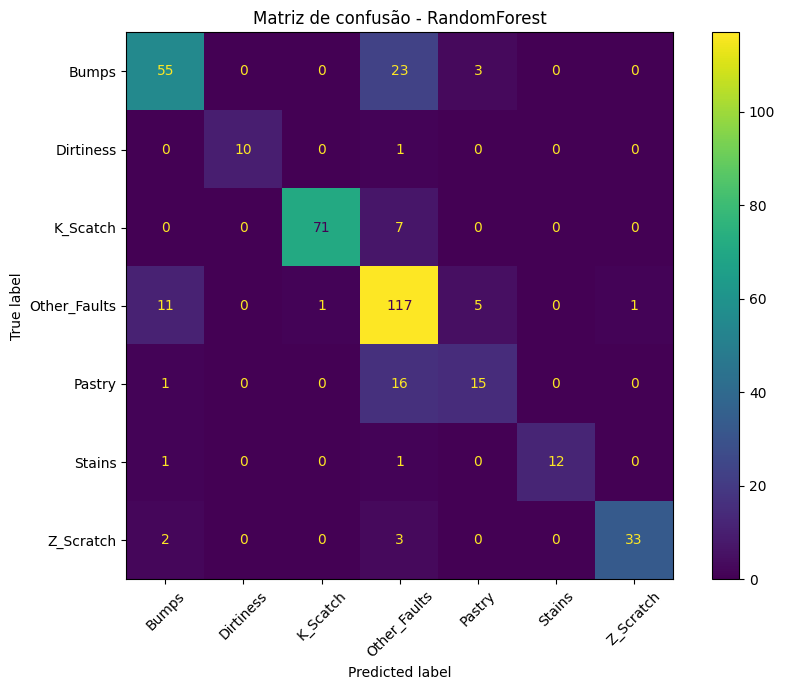

In [17]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, xticks_rotation=45)
plt.title(f"Matriz de confusão - {best_model_name}")
plt.tight_layout()
plt.show()

In [18]:
overfit_table = comparison[[
    "modelo", "train_f1_macro", "test_f1_macro", "train_accuracy", "test_accuracy"
]].copy()

overfit_table["gap_f1_macro"] = overfit_table["train_f1_macro"] - overfit_table["test_f1_macro"]
overfit_table.sort_values("test_f1_macro", ascending=False)

,modelo,train_f1_macro,test_f1_macro,train_accuracy,test_accuracy,gap_f1_macro
0,RandomForest,1.000000,0.826429,1.000000,0.804627,0.173571
4,RandomForest_Tuned,1.000000,0.818754,1.000000,0.799486,0.181246
1,HistGradientBoosting,1.000000,0.816603,1.000000,0.804627,0.183397
2,LogisticRegression,0.693010,0.636509,0.688789,0.645244,0.056501
3,Baseline_Dummy,0.073548,0.073610,0.346649,0.347044,-0.000062


Quando o resultado de treino fica muito acima do teste, existe sinal de overfitting. Quando os dois ficam baixos, o modelo provavelmente está simples demais ou faltam variáveis melhores.

Neste MVP, a escolha final considera o desempenho em teste, principalmente pelo F1 macro.

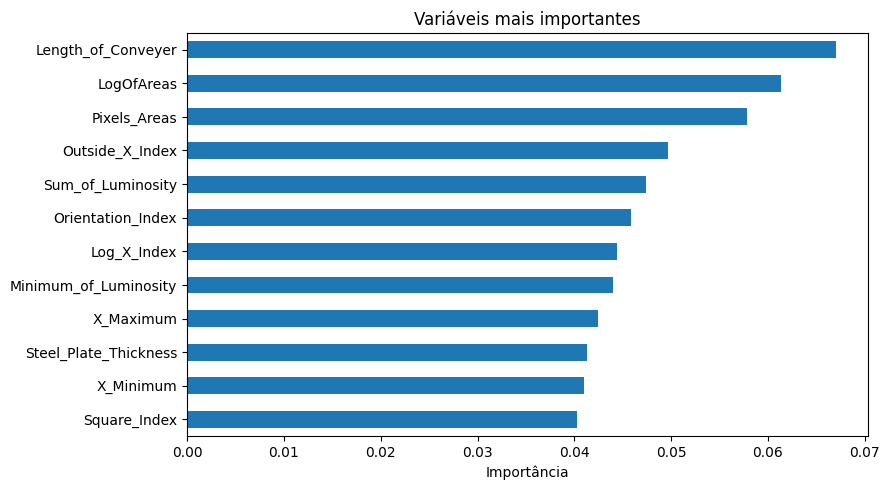

,atributo,importancia
0,Length_of_Conveyer,0.067018
1,LogOfAreas,0.061385
2,Pixels_Areas,0.057845
3,Outside_X_Index,0.049723
4,Sum_of_Luminosity,0.047453
5,Orientation_Index,0.045811
6,Log_X_Index,0.044408
7,Minimum_of_Luminosity,0.043950
8,X_Maximum,0.042425
9,Steel_Plate_Thickness,0.041345


In [19]:
model_core = best_model.named_steps["model"] if hasattr(best_model, "named_steps") else best_model

if hasattr(model_core, "feature_importances_"):
    importances = pd.Series(model_core.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)

    plt.figure(figsize=(9, 5))
    importances.head(12).sort_values().plot(kind="barh")
    plt.title("Variáveis mais importantes")
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.show()

    display(importances.head(12).reset_index().rename(columns={"index": "atributo", 0: "importancia"}))
else:
    print("O melhor modelo não possui importância de variáveis nativa.")

## 9. Conclusão

O MVP conseguiu montar um fluxo completo de classificação de defeitos em chapas de aço: carregamento dos dados, análise inicial, preparação, divisão treino/teste, baseline, comparação de modelos, otimização e avaliação final.

A melhor solução foi escolhida pelo F1 macro no teste, porque essa métrica trata todas as classes com o mesmo peso. Isso faz sentido aqui, já que nem todos os tipos de defeito aparecem na mesma frequência.

As principais limitações são: base relativamente pequena, dados antigos, ausência das imagens originais e falta de informação sobre o custo real de errar cada tipo de defeito. Em um cenário real, eu validaria o modelo com dados atuais da linha de produção e analisaria os erros junto com a equipe de qualidade.

In [20]:
best_row = comparison.iloc[0]

print(f"""
Resumo final
------------
Problema: classificação de defeitos em chapas de aço.
Dataset: Steel Plates Faults, UCI.
Melhor modelo: {best_row['modelo']}.
Acurácia em teste: {best_row['test_accuracy']:.4f}.
Balanced accuracy em teste: {best_row['test_balanced_accuracy']:.4f}.
F1 macro em teste: {best_row['test_f1_macro']:.4f}.
F1 weighted em teste: {best_row['test_f1_weighted']:.4f}.

O modelo superou o baseline e apresentou um resultado coerente para o objetivo do MVP.
Como próximo passo, eu testaria a solução com dados reais e avaliaria o impacto de cada tipo de erro no processo industrial.
""")


Resumo final
------------
Problema: classificação de defeitos em chapas de aço.
Dataset: Steel Plates Faults, UCI.
Melhor modelo: RandomForest.
Acurácia em teste: 0.8046.
Balanced accuracy em teste: 0.7942.
F1 macro em teste: 0.8264.
F1 weighted em teste: 0.8041.

O modelo superou o baseline e apresentou um resultado coerente para o objetivo do MVP.
Como próximo passo, eu testaria a solução com dados reais e avaliaria o impacto de cada tipo de erro no processo industrial.



## 10. Checklist

| Item | Resposta |
|---|---|
| Problema | Classificar defeitos em chapas de aço. |
| Objetivo | Prever a classe do defeito. |
| Tipo | Classificação multiclasse supervisionada. |
| Dataset | Steel Plates Faults, UCI. |
| Carga dos dados | URL pública, sem login/token/upload. |
| Atributos | 27 variáveis numéricas. |
| Alvo | `fault_type`, criado a partir das 7 colunas de defeito. |
| Valores ausentes | Verificados no notebook. |
| Vazamento de dados | As colunas originais de classe não entram em `X`. |
| Divisão | Treino/teste com estratificação. |
| Baseline | DummyClassifier. |
| Modelos | Regressão Logística, Random Forest e HistGradientBoosting. |
| Otimização | GridSearchCV no Random Forest. |
| Métrica principal | F1 macro. |
| Avaliação | Métricas em teste, relatório de classificação e matriz de confusão. |
| Limitações | Base pequena/antiga e sem custo real por tipo de erro. |
| Próximos passos | Testar com dados reais e analisar custos dos erros. |